# JPEG2000 Restoration (U-Net vs ViT)

workflow for:
- baseline U-Net and ViT restoration
- dual-domain supervision (spatial + FFT frequency)
- PSNR/SSIM/LPIPS comparison and architecture selection

Run all cells in order.

## 1) Runtime Setup and Dependency Installation


In [2]:
!nvidia-smi
!pip -q install --upgrade pip
!pip -q install torchvision lpips scikit-image opencv-python glymur imagecodecs

import torch
print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Wed Mar 18 19:38:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             32W /   70W |     417MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2) Project Paths, Split Validation, and Reproducibility Seeds

In [3]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

# Mount Drive only if it is not already mounted.
from google.colab import drive
if not Path('/content/drive/MyDrive').exists():
    drive.mount('/content/drive')

# Use absolute Colab path (not relative ./content/...)
DATA_ROOT = Path('/content/drive/MyDrive/data')

for split in ['train', 'validate', 'test']:
    split_dir = DATA_ROOT / split
    print(split, 'exists:', split_dir.exists())
    print('  compressed:', (split_dir / 'compressed').exists())
    print('  ground_truth:', (split_dir / 'ground_truth').exists())
    print('  compression_stats.csv:', (split_dir / 'compression_stats.csv').exists())

SEED = 414
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print('Seed set to', SEED)

train exists: True
  compressed: True
  ground_truth: True
  compression_stats.csv: True
validate exists: True
  compressed: True
  ground_truth: True
  compression_stats.csv: True
test exists: True
  compressed: True
  ground_truth: True
  compression_stats.csv: True
Seed set to 414


## 3) JPEG2000 Dataset Loader from compressed/, ground_truth/, and compression_stats.csv

In [4]:
import glymur
from PIL import Image
from torch.utils.data import Dataset

IMG_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}


def load_rgb(path: Path):
    if path.suffix.lower() == '.jp2':
        arr = np.array(glymur.Jp2k(str(path))[:], dtype=np.uint8)
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr], axis=-1)
        return arr
    return np.array(Image.open(path).convert('RGB'), dtype=np.uint8)


class JPEG2000PairDataset(Dataset):
    def __init__(self, data_root: Path, split: str, patch_size=128, train=True, return_meta=True):
        self.split = split
        self.patch_size = patch_size
        self.train = train
        self.return_meta = return_meta

        split_dir = data_root / split
        self.comp_dir = split_dir / 'compressed'
        self.gt_dir = split_dir / 'ground_truth'
        self.csv_path = split_dir / 'compression_stats.csv'

        meta = pd.read_csv(self.csv_path)
        meta['stem'] = meta['filename'].astype(str).str.replace('.jp2', '', regex=False)
        self.meta_map = {
            row['stem']: {
                'target_bpp': float(row['target_bpp']),
                'compression_ratio': float(row['compression_ratio'])
            }
            for _, row in meta.iterrows()
        }

        gt_lookup = {}
        for p in self.gt_dir.iterdir():
            if p.suffix.lower() in IMG_EXTS:
                gt_lookup[p.stem] = p

        self.pairs = []
        for comp in sorted(self.comp_dir.glob('*.jp2')):
            if comp.stem in gt_lookup:
                self.pairs.append((comp, gt_lookup[comp.stem]))

        if not self.pairs:
            raise RuntimeError(f'No pairs found for split={split}')

    def __len__(self):
        return len(self.pairs)

    def _crop_pair(self, comp, gt):
        h = min(comp.shape[0], gt.shape[0])
        w = min(comp.shape[1], gt.shape[1])
        comp = comp[:h, :w]
        gt = gt[:h, :w]

        if self.train:
            y = np.random.randint(0, h - self.patch_size + 1) if h > self.patch_size else 0
            x = np.random.randint(0, w - self.patch_size + 1) if w > self.patch_size else 0
        else:
            y = max((h - self.patch_size) // 2, 0)
            x = max((w - self.patch_size) // 2, 0)

        comp = comp[y:y+self.patch_size, x:x+self.patch_size]
        gt = gt[y:y+self.patch_size, x:x+self.patch_size]
        return comp, gt

    def __getitem__(self, idx):
        comp_path, gt_path = self.pairs[idx]
        comp = load_rgb(comp_path)
        gt = load_rgb(gt_path)
        comp, gt = self._crop_pair(comp, gt)

        if self.train and np.random.rand() < 0.5:
            comp = comp[:, ::-1].copy()
            gt = gt[:, ::-1].copy()
        if self.train and np.random.rand() < 0.5:
            comp = comp[::-1, :].copy()
            gt = gt[::-1, :].copy()

        x = torch.from_numpy(comp).permute(2, 0, 1).float() / 255.0
        y = torch.from_numpy(gt).permute(2, 0, 1).float() / 255.0

        sample = {'input': x, 'target': y, 'name': comp_path.stem}
        if self.return_meta:
            sample.update(self.meta_map.get(comp_path.stem, {'target_bpp': np.nan, 'compression_ratio': np.nan}))
        return sample

## 4) Training and Validation DataLoaders with Patch Sampling

In [5]:
from torch.utils.data import DataLoader

PATCH_SIZE = 128
BATCH_SIZE = 8
NUM_WORKERS = 2

train_ds = JPEG2000PairDataset(DATA_ROOT, 'train', patch_size=PATCH_SIZE, train=True)
val_ds = JPEG2000PairDataset(DATA_ROOT, 'validate', patch_size=PATCH_SIZE, train=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
)

print('train samples:', len(train_ds), 'val samples:', len(val_ds))

train samples: 8000 val samples: 1000


## 5) Baseline U-Net Restoration Model

In [6]:
import torch.nn as nn


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNetRestorer(nn.Module):
    def __init__(self, base=64):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        self.e1 = ConvBlock(3, base)
        self.e2 = ConvBlock(base, base * 2)
        self.e3 = ConvBlock(base * 2, base * 4)

        self.b = ConvBlock(base * 4, base * 4)

        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, 2)
        self.d2 = ConvBlock(base * 4, base * 2)

        self.u1 = nn.ConvTranspose2d(base * 2, base, 2, 2)
        self.d1 = ConvBlock(base * 2, base)

        self.head = nn.Conv2d(base, 3, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        b = self.b(e3)

        d2 = self.u2(b)
        d2 = self.d2(torch.cat([d2, e2], dim=1))

        d1 = self.u1(d2)
        d1 = self.d1(torch.cat([d1, e1], dim=1))

        return torch.clamp(x + self.head(d1), 0.0, 1.0)

## 6) Baseline ViT Restoration Model (Patch Embedding + Reconstruction Head)

In [7]:
class ViTRestorer(nn.Module):
    def __init__(self, image_size=128, patch=8, dim=256, depth=6, heads=8, mlp_ratio=4.0):
        super().__init__()
        assert image_size % patch == 0
        self.patch = patch
        self.grid = image_size // patch
        self.n_patches = self.grid * self.grid

        self.embed = nn.Conv2d(3, dim, kernel_size=patch, stride=patch)
        self.pos = nn.Parameter(torch.zeros(1, self.n_patches, dim))

        enc = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=heads,
            dim_feedforward=int(dim * mlp_ratio),
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc, num_layers=depth)

        self.head = nn.Sequential(
            nn.ConvTranspose2d(dim, 128, kernel_size=patch, stride=patch),
            nn.GELU(),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(64, 3, 3, padding=1),
        )

    def forward(self, x):
        b, c, h, w = x.shape
        assert h % self.patch == 0 and w % self.patch == 0

        feat = self.embed(x)  # [B, D, H/P, W/P]
        hp, wp = feat.shape[-2], feat.shape[-1]

        tok = feat.flatten(2).transpose(1, 2)  # [B, N, D]
        tok = tok + self.pos
        tok = self.encoder(tok)

        feat = tok.transpose(1, 2).reshape(b, -1, hp, wp)
        out = self.head(feat)
        return torch.clamp(x + out, 0.0, 1.0)

## 7) Dual-Domain Loss (Spatial + FFT Frequency)

In [8]:
import torch.nn.functional as F


class DualDomainLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=0.1, phase_weight=0.5):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.phase_weight = phase_weight

    def forward(self, pred, target):
        l_spatial = F.l1_loss(pred, target)

        pfft = torch.fft.rfft2(pred, norm='ortho')
        tfft = torch.fft.rfft2(target, norm='ortho')

        p_mag = torch.log1p(torch.abs(pfft))
        t_mag = torch.log1p(torch.abs(tfft))
        l_mag = F.l1_loss(p_mag, t_mag)

        p_phase = torch.angle(pfft)
        t_phase = torch.angle(tfft)
        l_phase = torch.mean(1.0 - torch.cos(p_phase - t_phase))

        l_freq = l_mag + self.phase_weight * l_phase
        total = self.alpha * l_spatial + self.beta * l_freq
        return total, l_spatial.detach(), l_freq.detach()

## 8) Training Loop for U-Net and ViT (AMP + Checkpoints)

In [9]:
import time
from collections import defaultdict
from tqdm.auto import tqdm


def build_model(name):
    if name == 'unet':
        return UNetRestorer(base=64).to(device)
    if name == 'vit':
        return ViTRestorer(image_size=PATCH_SIZE, patch=8, dim=256, depth=6, heads=8).to(device)
    raise ValueError(name)


def validate_epoch(model, loader, criterion, max_batches=None):
    model.eval()
    agg = defaultdict(float)
    n = 0
    with torch.no_grad():
        for bi, batch in enumerate(loader):
            if max_batches is not None and bi >= max_batches:
                break
            x = batch['input'].to(device, non_blocking=True)
            y = batch['target'].to(device, non_blocking=True)
            pred = model(x)
            total, l_sp, l_fr = criterion(pred, y)
            agg['loss'] += total.item()
            agg['l_spatial'] += l_sp.item()
            agg['l_freq'] += l_fr.item()
            n += 1
    for k in agg:
        agg[k] /= max(n, 1)
    return dict(agg)


def train_model(
    model_name,
    epochs=5,
    lr=2e-4,
    weight_decay=1e-4,
    alpha=1.0,
    beta=0.1,
    phase_weight=0.5,
    grad_clip=1.0,
    train_max_steps=None,
    val_max_batches=8,
    train_loader_override=None,
    val_loader_override=None,
):
    model = build_model(model_name)
    criterion = DualDomainLoss(alpha=alpha, beta=beta, phase_weight=phase_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1))
    scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

    tloader = train_loader_override if train_loader_override is not None else train_loader
    vloader = val_loader_override if val_loader_override is not None else val_loader

    save_dir = Path('/content/checkpoints')
    save_dir.mkdir(parents=True, exist_ok=True)
    best_path = save_dir / f'{model_name}_best.pt'

    history = []
    best_lpips = float('inf')
    best_psnr = -1.0

    total_train_steps = len(tloader)
    if train_max_steps is not None:
        total_train_steps = min(total_train_steps, train_max_steps)

    for ep in range(1, epochs + 1):
        if device.type == 'cuda':
            torch.cuda.reset_peak_memory_stats()

        t0 = time.time()
        model.train()

        run = defaultdict(float)
        steps = 0

        pbar = tqdm(
            tloader,
            total=total_train_steps,
            desc=f"{model_name} | epoch {ep}/{epochs}",
            leave=False,
            dynamic_ncols=True,
        )

        for bi, batch in enumerate(pbar):
            if train_max_steps is not None and bi >= train_max_steps:
                break

            x = batch['input'].to(device, non_blocking=True)
            y = batch['target'].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                pred = model(x)
                total, l_sp, l_fr = criterion(pred, y)

            scaler.scale(total).backward()
            if grad_clip is not None and grad_clip > 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()

            run['train_loss'] += total.item()
            run['train_l_spatial'] += l_sp.item()
            run['train_l_freq'] += l_fr.item()
            steps += 1

            if steps % 5 == 0:
                pbar.set_postfix(
                    loss=f"{run['train_loss'] / steps:.4f}",
                    sp=f"{run['train_l_spatial'] / steps:.4f}",
                    fr=f"{run['train_l_freq'] / steps:.4f}",
                    refresh=False,
                )

        scheduler.step()

        for k in run:
            run[k] /= max(steps, 1)

        print(f"[{model_name}] epoch {ep}: running validation...")
        val = validate_epoch(model, vloader, criterion, max_batches=val_max_batches)
        print(f"[{model_name}] epoch {ep}: running PSNR/SSIM/LPIPS...")
        val_metrics = compute_validation_metrics(model, vloader, max_batches=val_max_batches)
        elapsed = time.time() - t0

        row = {
            'model': model_name,
            'epoch': ep,
            'time_sec': elapsed,
            'train_steps': steps,
            **run,
            **val,
            **val_metrics,
            'max_memory_gb': torch.cuda.max_memory_allocated() / (1024 ** 3) if device.type == 'cuda' else 0.0,
        }
        history.append(row)

        print(
            f"[{model_name}] ep={ep:02d} steps={steps} "
            f"train={row['train_loss']:.4f} val={row['loss']:.4f} "
            f"PSNR={row['psnr']:.2f} SSIM={row['ssim']:.4f} LPIPS={row['lpips']:.4f} "
            f"time={row['time_sec']:.1f}s"
        )

        is_better = (row['lpips'] < best_lpips) or (abs(row['lpips'] - best_lpips) < 1e-6 and row['psnr'] > best_psnr)
        if is_better:
            best_lpips = row['lpips']
            best_psnr = row['psnr']
            torch.save({'model': model.state_dict(), 'epoch': ep, 'row': row}, best_path)

    return model, pd.DataFrame(history), best_path

## 9) Validation Metrics: PSNR, SSIM, LPIPS

In [10]:
import lpips

_lpips_metric = lpips.LPIPS(net='alex').to(device)
_lpips_metric.eval()


def psnr_torch(pred, target, eps=1e-8):
    mse = F.mse_loss(pred, target)
    return (10.0 * torch.log10(1.0 / (mse + eps))).item()


def ssim_torch(pred, target, w=11, eps=1e-8):
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2
    p = w // 2

    mx = F.avg_pool2d(pred, w, stride=1, padding=p)
    my = F.avg_pool2d(target, w, stride=1, padding=p)
    vx = F.avg_pool2d(pred * pred, w, stride=1, padding=p) - mx * mx
    vy = F.avg_pool2d(target * target, w, stride=1, padding=p) - my * my
    vxy = F.avg_pool2d(pred * target, w, stride=1, padding=p) - mx * my

    num = (2 * mx * my + c1) * (2 * vxy + c2)
    den = (mx * mx + my * my + c1) * (vx + vy + c2)
    return (num / (den + eps)).mean().item()


def compute_validation_metrics(model, loader, max_batches=20):
    model.eval()
    pvals, svals, lvals = [], [], []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= max_batches:
                break
            x = batch['input'].to(device, non_blocking=True)
            y = batch['target'].to(device, non_blocking=True)
            pred = model(x)

            pvals.append(psnr_torch(pred, y))
            svals.append(ssim_torch(pred, y))

            l = _lpips_metric(pred * 2 - 1, y * 2 - 1).mean().item()
            lvals.append(l)

    return {
        'psnr': float(np.mean(pvals)) if pvals else np.nan,
        'ssim': float(np.mean(svals)) if svals else np.nan,
        'lpips': float(np.mean(lvals)) if lvals else np.nan,
    }

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


## 10) Architecture Comparison Table and Best-Model Selection

In [11]:
# Quick sanity run (very fast): tiny subset + capped steps
from torch.utils.data import Subset, DataLoader

tiny_train_ds = Subset(train_ds, range(min(256, len(train_ds))))
tiny_val_ds = Subset(val_ds, range(min(64, len(val_ds))))

tiny_train_loader = DataLoader(tiny_train_ds, batch_size=4, shuffle=True, num_workers=0, pin_memory=(device.type == 'cuda'))
tiny_val_loader = DataLoader(tiny_val_ds, batch_size=4, shuffle=False, num_workers=0, pin_memory=(device.type == 'cuda'))

sanity_model, sanity_hist, sanity_ckpt = train_model(
    'unet',
    epochs=1,
    alpha=1.0,
    beta=0.1,
    phase_weight=0.5,
    train_max_steps=10,
    val_max_batches=4,
    train_loader_override=tiny_train_loader,
    val_loader_override=tiny_val_loader,
)

sanity_hist.tail(1)

unet | epoch 1/1:   0%|          | 0/10 [00:00<?, ?it/s]

[unet] epoch 1: running validation...
[unet] epoch 1: running PSNR/SSIM/LPIPS...
[unet] ep=01 steps=10 train=0.1104 val=0.1126 PSNR=20.65 SSIM=0.6463 LPIPS=0.4584 time=68.7s


,model,epoch,time_sec,train_steps,train_loss,train_l_spatial,train_l_freq,loss,l_spatial,l_freq,psnr,ssim,lpips,max_memory_gb
0,unet,1,68.731177,10,0.110438,0.0667,0.437385,0.112629,0.068458,0.441715,20.652104,0.646299,0.458373,0.181336


In [12]:
# Fast sanity check: single training step on one batch
from itertools import islice

tiny_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=0, pin_memory=(device.type == 'cuda'))
model = build_model('unet')
criterion = DualDomainLoss(alpha=1.0, beta=0.1, phase_weight=0.5)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

batch = next(iter(tiny_loader))
x = batch['input'].to(device)
y = batch['target'].to(device)

model.train()
optimizer.zero_grad(set_to_none=True)
with torch.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
    pred = model(x)
    total, l_sp, l_fr = criterion(pred, y)

total.backward()
optimizer.step()

print('Single-step sanity OK | total:', float(total.detach().cpu()), '| spatial:', float(l_sp.cpu()), '| freq:', float(l_fr.cpu()))

Single-step sanity OK | total: 0.11878998577594757 | spatial: 0.07202304899692535 | freq: 0.46766936779022217


In [13]:
from torch.utils.data import Subset, DataLoader

# Toggle this to switch between fast iteration and full experiment
QUICK_MODE = True

if QUICK_MODE:
    EPOCHS = 3
    TRAIN_MAX_STEPS = 120
    VAL_MAX_BATCHES = 6

    quick_train_ds = Subset(train_ds, range(min(1200, len(train_ds))))
    quick_val_ds = Subset(val_ds, range(min(300, len(val_ds))))

    exp_train_loader = DataLoader(quick_train_ds, batch_size=4, shuffle=True, num_workers=0, pin_memory=(device.type == 'cuda'))
    exp_val_loader = DataLoader(quick_val_ds, batch_size=4, shuffle=False, num_workers=0, pin_memory=(device.type == 'cuda'))
else:
    EPOCHS = 5
    TRAIN_MAX_STEPS = None
    VAL_MAX_BATCHES = 20
    exp_train_loader = train_loader
    exp_val_loader = val_loader

print('Starting comparison run: U-Net then ViT')
print(f'Config -> QUICK_MODE={QUICK_MODE}, epochs={EPOCHS}, train_max_steps={TRAIN_MAX_STEPS}, val_max_batches={VAL_MAX_BATCHES}')

print('\n[1/2] Training U-Net...')
unet_model, unet_hist, unet_ckpt = train_model(
    'unet',
    epochs=EPOCHS,
    alpha=1.0,
    beta=0.1,
    phase_weight=0.5,
    train_max_steps=TRAIN_MAX_STEPS,
    val_max_batches=VAL_MAX_BATCHES,
    train_loader_override=exp_train_loader,
    val_loader_override=exp_val_loader,
)

print('\n[2/2] Training ViT...')
vit_model, vit_hist, vit_ckpt = train_model(
    'vit',
    epochs=EPOCHS,
    alpha=1.0,
    beta=0.1,
    phase_weight=0.5,
    train_max_steps=TRAIN_MAX_STEPS,
    val_max_batches=VAL_MAX_BATCHES,
    train_loader_override=exp_train_loader,
    val_loader_override=exp_val_loader,
)

last_unet = unet_hist.iloc[-1]
last_vit = vit_hist.iloc[-1]

summary = pd.DataFrame([
    {
        'model': 'unet',
        'psnr': last_unet['psnr'],
        'ssim': last_unet['ssim'],
        'lpips': last_unet['lpips'],
        'time_per_epoch_sec': unet_hist['time_sec'].mean(),
        'max_memory_gb': unet_hist['max_memory_gb'].max(),
        'train_steps': int(last_unet['train_steps']),
        'best_ckpt': str(unet_ckpt),
    },
    {
        'model': 'vit',
        'psnr': last_vit['psnr'],
        'ssim': last_vit['ssim'],
        'lpips': last_vit['lpips'],
        'time_per_epoch_sec': vit_hist['time_sec'].mean(),
        'max_memory_gb': vit_hist['max_memory_gb'].max(),
        'train_steps': int(last_vit['train_steps']),
        'best_ckpt': str(vit_ckpt),
    },
])

summary = summary.sort_values(by=['lpips', 'psnr'], ascending=[True, False]).reset_index(drop=True)
summary

Starting comparison run: U-Net then ViT
Config -> QUICK_MODE=True, epochs=3, train_max_steps=120, val_max_batches=6

[1/2] Training U-Net...


unet | epoch 1/3:   0%|          | 0/120 [00:00<?, ?it/s]

[unet] epoch 1: running validation...
[unet] epoch 1: running PSNR/SSIM/LPIPS...
[unet] ep=01 steps=120 train=0.1077 val=0.1108 PSNR=20.79 SSIM=0.6374 LPIPS=0.5078 time=594.3s


unet | epoch 2/3:   0%|          | 0/120 [00:00<?, ?it/s]

[unet] epoch 2: running validation...
[unet] epoch 2: running PSNR/SSIM/LPIPS...
[unet] ep=02 steps=120 train=0.1047 val=0.1105 PSNR=20.81 SSIM=0.6392 LPIPS=0.5066 time=275.8s


...

vit | epoch 2/3:   0%|          | 0/120 [00:00<?, ?it/s]

[vit] epoch 2: running validation...
[vit] epoch 2: running PSNR/SSIM/LPIPS...
[vit] ep=02 steps=120 train=0.1061 val=0.1108 PSNR=20.79 SSIM=0.6367 LPIPS=0.5016 time=29.6s


vit | epoch 3/3:   0%|          | 0/120 [00:00<?, ?it/s]

[vit] epoch 3: running validation...
[vit] epoch 3: running PSNR/SSIM/LPIPS...
[vit] ep=03 steps=120 train=0.1093 val=0.1107 PSNR=20.79 SSIM=0.6374 LPIPS=0.5045 time=13.7s


,model,psnr,ssim,lpips,time_per_epoch_sec,max_memory_gb,train_steps,best_ckpt
0,unet,20.816378,0.639789,0.504257,314.348525,0.254187,120,/content/checkpoints/unet_best.pt
1,vit,20.793948,0.637379,0.504488,28.961240,0.366079,120,/content/checkpoints/vit_best.pt


## 11) Qualitative Visualization: Input vs Output vs Ground Truth

Batch mean metrics:
  Input   -> PSNR 22.08, SSIM 0.6176, LPIPS 0.5101
  Restored-> PSNR 22.11, SSIM 0.6194, LPIPS 0.5070


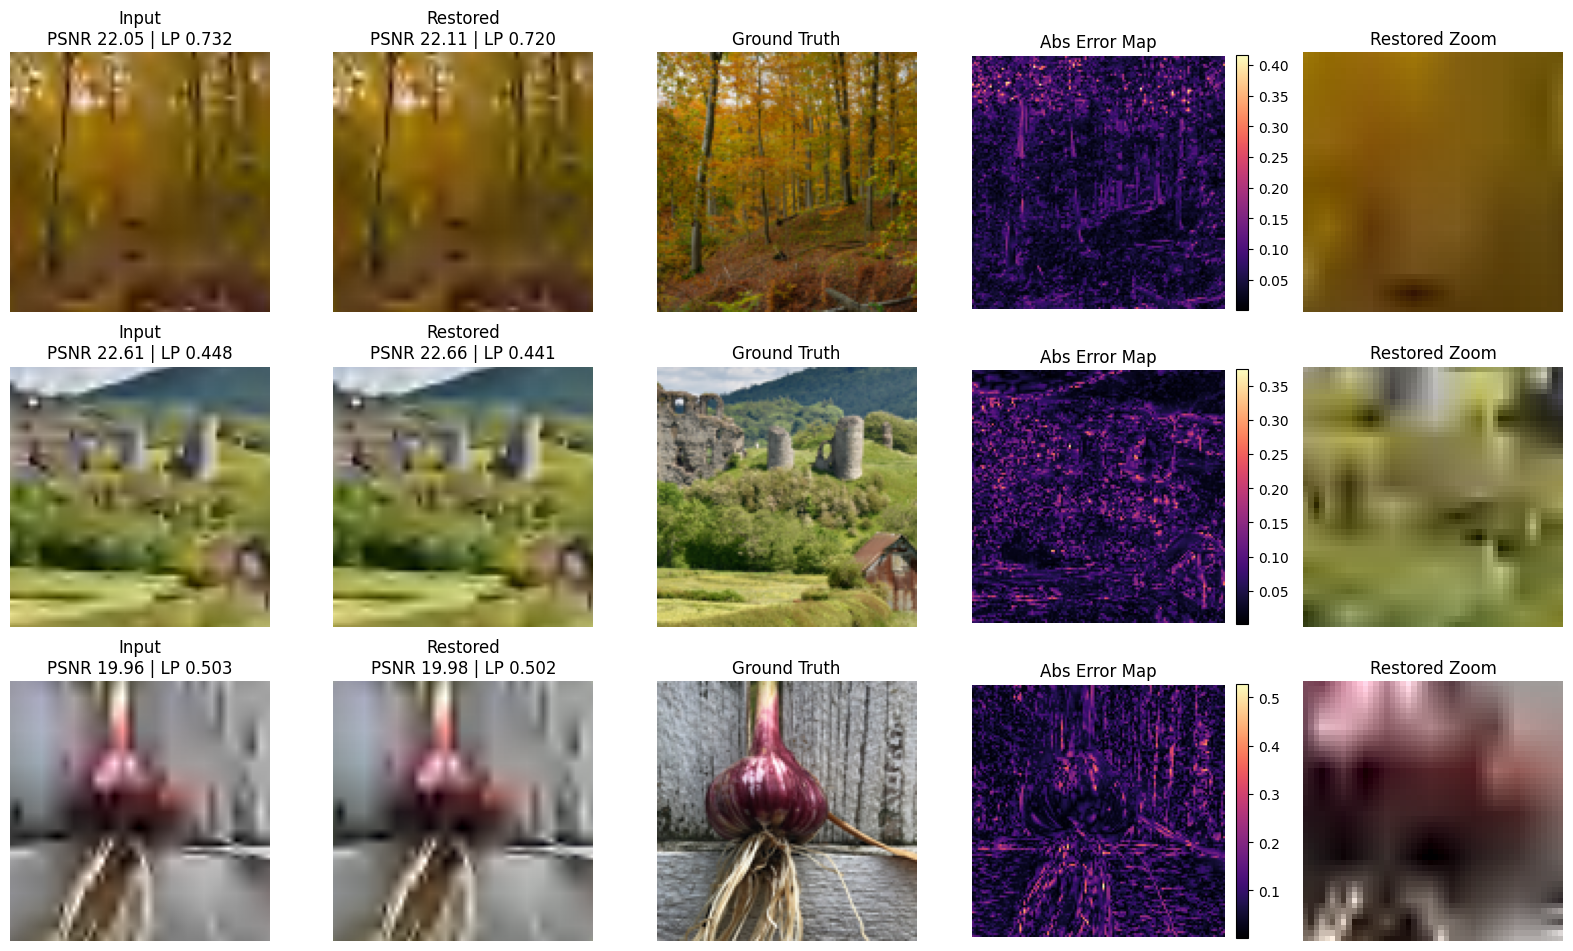

In [14]:
import matplotlib.pyplot as plt


def _batch_lpips(a, b):
    # a, b are in [0,1], returns per-image LPIPS
    with torch.no_grad():
        v = _lpips_metric(a * 2 - 1, b * 2 - 1)
    return v.view(v.shape[0], -1).mean(dim=1)


def _batch_psnr(a, b, eps=1e-8):
    mse = ((a - b) ** 2).flatten(1).mean(dim=1)
    return 10.0 * torch.log10(1.0 / (mse + eps))


def _batch_ssim(a, b):
    vals = []
    for i in range(a.shape[0]):
        vals.append(ssim_torch(a[i:i+1], b[i:i+1]))
    return torch.tensor(vals, device=a.device)


def show_triplet(model, loader, n=3, zoom=48):
    model.eval()
    batch = next(iter(loader))
    x = batch['input'].to(device)
    y = batch['target'].to(device)

    with torch.no_grad():
        p = model(x)

    lp_in = _batch_lpips(x, y)
    lp_out = _batch_lpips(p, y)
    ps_in = _batch_psnr(x, y)
    ps_out = _batch_psnr(p, y)
    ss_in = _batch_ssim(x, y)
    ss_out = _batch_ssim(p, y)

    improvement = lp_in - lp_out
    best_idx = torch.argsort(improvement, descending=True)[:n]

    print('Batch mean metrics:')
    print(f"  Input   -> PSNR {ps_in.mean().item():.2f}, SSIM {ss_in.mean().item():.4f}, LPIPS {lp_in.mean().item():.4f}")
    print(f"  Restored-> PSNR {ps_out.mean().item():.2f}, SSIM {ss_out.mean().item():.4f}, LPIPS {lp_out.mean().item():.4f}")

    x_np = x.detach().cpu().permute(0, 2, 3, 1).numpy()
    y_np = y.detach().cpu().permute(0, 2, 3, 1).numpy()
    p_np = p.detach().cpu().permute(0, 2, 3, 1).numpy()

    fig, axes = plt.subplots(n, 5, figsize=(16, 3.2 * n))
    if n == 1:
        axes = axes[None, ...]

    for row, idx_t in enumerate(best_idx):
        idx = int(idx_t.item())
        inp = np.clip(x_np[idx], 0, 1)
        out = np.clip(p_np[idx], 0, 1)
        gt = np.clip(y_np[idx], 0, 1)
        diff = np.abs(out - gt).mean(axis=2)

        h, w = inp.shape[:2]
        cy, cx = h // 2, w // 2
        hs = min(zoom // 2, cy, cx)
        y0, y1 = cy - hs, cy + hs
        x0, x1 = cx - hs, cx + hs

        axes[row, 0].imshow(inp)
        axes[row, 0].set_title(f"Input\nPSNR {ps_in[idx]:.2f} | LP {lp_in[idx]:.3f}")
        axes[row, 1].imshow(out)
        axes[row, 1].set_title(f"Restored\nPSNR {ps_out[idx]:.2f} | LP {lp_out[idx]:.3f}")
        axes[row, 2].imshow(gt)
        axes[row, 2].set_title('Ground Truth')
        im = axes[row, 3].imshow(diff, cmap='magma')
        axes[row, 3].set_title('Abs Error Map')
        plt.colorbar(im, ax=axes[row, 3], fraction=0.046, pad=0.04)
        axes[row, 4].imshow(out[y0:y1, x0:x1])
        axes[row, 4].set_title('Restored Zoom')

        for c in range(5):
            axes[row, c].axis('off')

    plt.tight_layout()
    plt.show()


best_model_name = summary.iloc[0]['model']
best_model = unet_model if best_model_name == 'unet' else vit_model

# Use the same validation loader used in the comparison run when available.
vis_loader = exp_val_loader if 'exp_val_loader' in globals() else val_loader
show_triplet(best_model, vis_loader, n=3, zoom=48)

## 12) Checkpoint Export and Inference Cell for New .jp2 Inputs

In [15]:
def load_checkpoint(model_name, ckpt_path):
    model = build_model(model_name)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state['model'])
    model.eval()
    return model


def infer_single_jp2(model, jp2_path, out_path):
    arr = load_rgb(Path(jp2_path))
    x = torch.from_numpy(arr).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    x = x.to(device)

    with torch.no_grad():
        pred = model(x)

    out = (pred.squeeze(0).detach().cpu().permute(1, 2, 0).numpy() * 255.0).clip(0, 255).astype(np.uint8)
    Image.fromarray(out).save(out_path)
    return out_path


best_ckpt = summary.iloc[0]['best_ckpt']
best_name = summary.iloc[0]['model']
loaded_best = load_checkpoint(best_name, best_ckpt)

# Example inference path (edit these):
example_in = DATA_ROOT / 'test' / 'compressed' / '1.jp2'
example_out = Path('/content') / f'restored_{best_name}_1.png'

if example_in.exists():
    saved = infer_single_jp2(loaded_best, example_in, example_out)
    print('Saved:', saved)
else:
    print('Set example_in to a valid .jp2 file and rerun.')

# Optional export for Lab 4 reuse:
export_path = Path('/content') / f'{best_name}_lab3_weights.pt'
torch.save(loaded_best.state_dict(), export_path)
print('Exported weights:', export_path)

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 158 but got size 159 for tensor number 1 in the list.